In [31]:
# Standard scientific libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize

# Set plotting style for better visualization
plt.style.use("seaborn-v0_8")

Viral Load Data:
   time  value
0     0  2.584
1     8  3.232
2    24  5.976
3    48  7.907
4    72  7.869 

Interferon Data:
   time   value
0     0   2.138
1     8   5.896
2    24  14.384
3    48  17.235
4    72  25.853


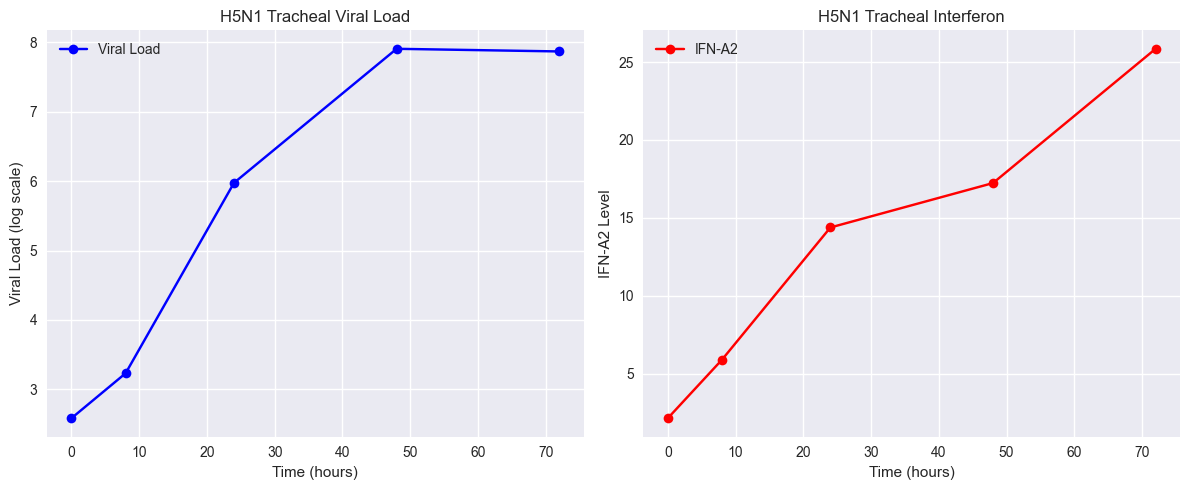

In [32]:
vl_path = "/Users/arjansuri/Desktop/Coding/TCU/BirdFlu/data/tracheal_data/h5n1(2022)/tracheal_h5n1_2022_vl.txt"
t1_path = "/Users/arjansuri/Desktop/Coding/TCU/BirdFlu/data/tracheal_data/h5n1(2022)/tracheal_h5n1_2022_t1.txt"

# Load the viral load data
vl_data = pd.read_csv(vl_path)
print("Viral Load Data:")
print(vl_data, "\n")

# Load the interferon data
t1_data = pd.read_csv(t1_path)
print("Interferon Data:")
print(t1_data)

# Let's also create a simple plot to visualize our data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot viral load data
ax1.plot(vl_data['time'], vl_data['value'], 'o-', color='blue', label='Viral Load')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Viral Load (log scale)')
ax1.set_title('H5N1 Tracheal Viral Load')
ax1.legend()

# Plot interferon data
ax2.plot(t1_data['time'], t1_data['value'], 'o-', color='red', label='IFN-A2')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('IFN-A2 Level')
ax2.set_title('H5N1 Tracheal Interferon')
ax2.legend()

plt.tight_layout()
plt.savefig('tracheal_h5n1_2022.png')
plt.show()

In [33]:
def Model(y, t, beta, gamma, rho, delta, p, c, alpha):
    """
    Extended model with resistant cell class
    
    Parameters:
    y: list of variables [T, R, I, V, F]
    t: time points
    beta: infection rate
    gamma: rate of conversion to resistant state
    rho: rate of return from resistant state
    delta: death rate of infected cells
    p: virus production rate
    c: virus clearance rate
    alpha: interferon clearance rate
    """
    T, R, I, V, F = y
    
    # System of ODEs
    dTdt = -beta * T * V - gamma * T * F    # Target cells
    dRdt = gamma * T * F - rho * R          # Resistant cells
    dIdt = beta * T * V - delta * I         # Infected cells
    dVdt = p * I - c * V                    # Virus
    dFdt = I - alpha * F                    # Interferon
    
    return [dTdt, dRdt, dIdt, dVdt, dFdt]

# Initial conditions
T0 = 1.0     # Initial target cells (normalized)
R0 = 0.0     # Initial resistant cells
I0 = 0.0     # Initial infected cells
V0 = vl_data['value'].iloc[0]    # Initial virus from data
F0 = t1_data['value'].iloc[0]    # Initial interferon from data
y0 = [T0, R0, I0, V0, F0]

print("Initial conditions:")
for var, val in zip(['T0', 'R0', 'I0', 'V0', 'F0'], y0):
    print(f"{var} = {val}")

Initial conditions:
T0 = 1.0
R0 = 0.0
I0 = 0.0
V0 = 2.584
F0 = 2.138


In [34]:
# Create two sets of time points:
# 1. Data time points for comparison
data_times = np.array([0, 8, 24, 48, 72])

# 2. Integration time points (finer mesh for solving ODEs)
t = np.linspace(0, 72, 100)

def optimize(params):
    """
    Objective function to minimize.
    Uses relative error at actual data time points.
    """
    beta, gamma, rho, delta, p, c, alpha = params
    
    try:
        # Solve ODE system
        solution = odeint(Model, y0, t, args=(beta, gamma, rho, delta, p, c, alpha))
        _, _, _, V, F = solution.T
        
        # Get model predictions at data time points
        # Find indices in t that correspond to data_times
        indices = [np.where(np.isclose(t, time))[0][0] for time in data_times]
        global V_model, F_model
        V_model = V[indices]
        F_model = F[indices]
        
        # Calculate relative SSR
        vl_ssr = np.sum((((np.maximum(V_model, 0)) - vl_data['value'])/vl_data['value'])**2)
        ifn_ssr = np.sum(((F_model - t1_data['value'])/t1_data['value'])**2)
        
        total_ssr = vl_ssr + ifn_ssr
        
        print(f"Parameters: {params} | SSR: {total_ssr}")
        return total_ssr
    except:
        return 1e12  # Large number if integration fails

print("Data time points:", data_times)
print("\nNumber of integration points:", len(t))
print("Integration time range:", t[0], "to", t[-1])

Data time points: [ 0  8 24 48 72]

Number of integration points: 100
Integration time range: 0.0 to 72.0


In [35]:
# guess =  [5, 2, .1, 0.3, 0.2, 1]
# guess =  [8.343820383462457, 0.14227915640397182, 24.999803292031743, 1.0000000000000006e-06, 9.943491537961386, 99.99999705549871]
# guess =  [14.99962824221421, 0.14325122860273118, 25.0, 1.0041844271121745e-06, 9.999991155086164, 99.99999433433749]
# guess =  [18157.22935023227, 0.2675500608913878, 3188.941873829718, -0.0044186634094281335, 121.52095549498222, 102099.2414743583]
# guess =  [12.462564035211152, 0.26890545724797177, 24.4609077003097, 0.004419028064124291, 16.60630496689475, 10.03528493777]
# guess =  [33.7023621186502087, 0.11169188982976419, 6.500142109750015, 0.002728635855545944, 12.962759191783146, 24.97498620729047]
# guess =  [np.float64(9.73022706705976), np.float64(0.14705740036139425), np.float64(10.482899086173001), np.float64(0.0001001617005785607), np.float64(19.586219970862402), np.float64(49.99931161312256)]
# guess =  [np.float64(95.02768120275016), np.float64(0.03851942379976944), np.float64(99.9956199846182), np.float64(0.0014071999313988474), np.float64(0.0001000000000000026), np.float64(12.033396988200224)]
# guess =  [np.float64(99.95319080865168), np.float64(0.03677078825573739), np.float64(2.031858793925287), np.float64(0.00010000000000000005), np.float64(0.00010000000000000015), np.float64(0.3836716139186588)]
guess = [0.1, 0.1, 0.1, 0.1, 10.0, 0.1, 0.1]

In [36]:
bounds = [
    (1e-6, 10.0),   # beta
    (1e-6, 10.0),   # gamma
    (1e-6, 10.0),   # rho 
    (1e-6, 10.0),   # delta
    (1e-1, 1e7), #p
    (1e-6, 10.0),   # c
    (1e-6, 100.0)    # alpha
]

print("Initial parameter guesses:")
for param, value in zip(['beta', 'gamma', 'rho', 'delta', 'p', 'c', 'alpha'], guess):
    print(f"{param}: {value}")
    print(f"{param}: {value}")

Initial parameter guesses:
beta: 0.1
beta: 0.1
gamma: 0.1
gamma: 0.1
rho: 0.1
rho: 0.1
delta: 0.1
delta: 0.1
p: 10.0
p: 10.0
c: 0.1
c: 0.1
alpha: 0.1
alpha: 0.1


In [37]:
# Perform optimization
result = minimize(optimize, guess, method ='Nelder-Mead', bounds=bounds)

# Extract optimized parameters
beta_fit, gamma_fit, rho_fit, delta_fit, p_fit, c_fit, alpha_fit = result.x

# Generate solution with optimized parameters
solution_fit = odeint(Model, y0, t, args=(beta_fit, gamma_fit, rho_fit, delta_fit, p_fit, c_fit, alpha_fit))
T_fit, R_fit, I_fit, V_fit, F_fit = solution_fit.T

# Print optimization results
print("Optimization successful:", result.success)
print("Number of iterations:", result.nit)
print("\nOptimized parameters:")
param_names = ['beta', 'gamma', 'rho', 'delta', 'p', 'c', 'alpha']
for name, value in zip(param_names, result.x):
    print(f"{name}: {value:.6f}")

print("guess = ", [i for i in result.x])

Parameters: [ 0.1  0.1  0.1  0.1 10.   0.1  0.1] | SSR: 46.401368088742444
Parameters: [ 0.105  0.1    0.1    0.1   10.     0.1    0.1  ] | SSR: 48.10786008085946
Parameters: [ 0.1    0.105  0.1    0.1   10.     0.1    0.1  ] | SSR: 44.76004775251795
Parameters: [ 0.1    0.1    0.105  0.1   10.     0.1    0.1  ] | SSR: 46.401368088742444
Parameters: [ 0.1    0.1    0.1    0.105 10.     0.1    0.1  ] | SSR: 44.620383860950234
Parameters: [ 0.1  0.1  0.1  0.1 10.5  0.1  0.1] | SSR: 51.98361361341298
Parameters: [ 0.1    0.1    0.1    0.1   10.     0.105  0.1  ] | SSR: 44.31430914793026
Parameters: [ 0.1    0.1    0.1    0.1   10.     0.1    0.105] | SSR: 46.607951019799685
Parameters: [0.10142857 0.10142857 0.10142857 0.10142857 9.5        0.10142857
 0.10142857] | SSR: 40.288747196628314
Parameters: [0.10214286 0.10214286 0.10214286 0.10214286 9.         0.10214286
 0.10214286] | SSR: 35.209666299917586
Parameters: [0.09561224 0.10204082 0.10204082 0.10204082 9.71428571 0.10204082
 0.10


Final SSR: 0.053757


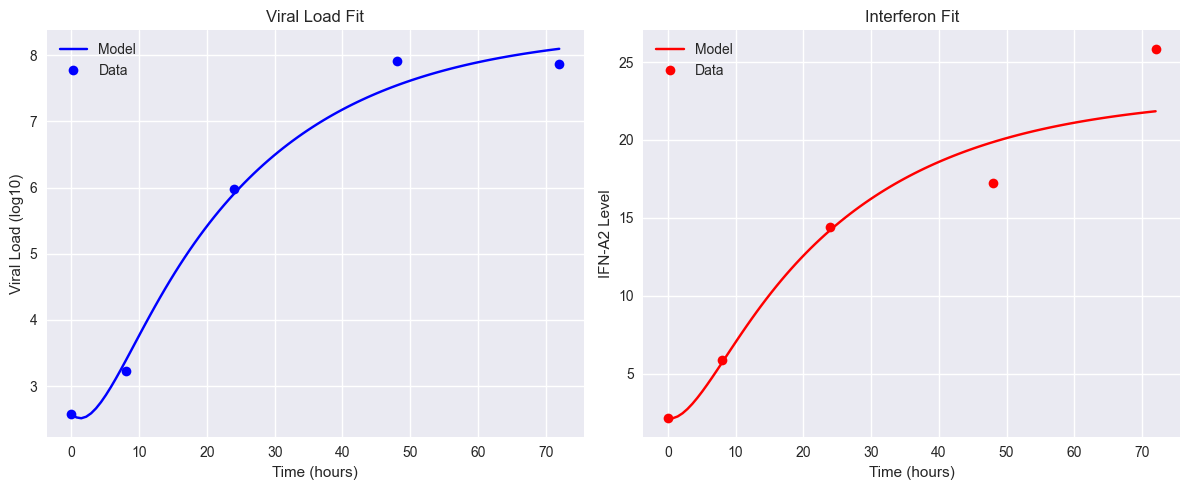

In [38]:
# Calculate final SSR
final_ssr = result.fun
print(f"\nFinal SSR: {final_ssr:.6f}")

# Plot results
plt.figure(figsize=(12, 5))

# Plot viral load
plt.subplot(121)
plt.plot(t, (V_fit), 'b-', label='Model')
plt.plot(vl_data['time'], vl_data['value'], 'bo', label='Data')
plt.xlabel('Time (hours)')
plt.ylabel('Viral Load (log10)')
plt.legend()
plt.title('Viral Load Fit')

# Plot interferon
plt.subplot(122)
plt.plot(t, F_fit, 'r-', label='Model')
plt.plot(t1_data['time'], t1_data['value'], 'ro', label='Data')
plt.xlabel('Time (hours)')
plt.ylabel('IFN-A2 Level')
plt.legend()
plt.title('Interferon Fit')

plt.tight_layout()
plt.savefig("nasal_fit_h5n1_2022.png")
plt.show()

In [39]:
# %% Bootstrap Analysis
import os

# Create output directory
strain = "h5n1(2022)"  # Change for each file
location = "tracheal"     # Change for each file
output_dir = f"/Users/arjansuri/Desktop/Coding/TCU/BirdFlu/code/model3/{strain}/{location}/bootstrap_results"
os.makedirs(output_dir, exist_ok=True)
output_prefix = f"{output_dir}/{strain}_{location}"

# Calculate residuals between data and best-fit model
# Find indices for data_times in t
indices = [np.where(np.isclose(t, time))[0][0] for time in data_times]
V_best = V_fit[indices]
F_best = F_fit[indices]

# Calculate residuals (use for bootstrapping)
residuals_viral = vl_data['value'] - V_best
residuals_ifn = t1_data['value'] - F_best

# Use best-fit parameters from previous optimization
best_params = [beta_fit, gamma_fit, rho_fit, delta_fit, p_fit, c_fit, alpha_fit]

# Define bootstrap optimization function that uses relative error
def optimize_bootstrap(params, new_viral_data, new_ifn_data):
    """
    Objective function for bootstrap optimization.
    Uses relative error just like the original optimize function.
    """
    beta, gamma, rho, delta, p, c, alpha = params
    
    try:
        # Solve ODE system
        solution = odeint(Model, y0, t, args=(beta, gamma, rho, delta, p, c, alpha))
        _, _, _, V, F = solution.T
        
        # Get model predictions at data time points
        indices = [np.where(np.isclose(t, time))[0][0] for time in data_times]
        V_pred = V[indices]
        F_pred = F[indices]
        
        # Calculate relative SSR (same method as in original optimize function)
        vl_ssr = np.sum((((np.maximum(V_pred, 0)) - new_viral_data)/new_viral_data)**2)
        ifn_ssr = np.sum(((F_pred - new_ifn_data)/new_ifn_data)**2)
        
        total_ssr = vl_ssr + ifn_ssr
        return total_ssr
    except:
        return 1e12  # Large number if integration fails

# Target number of successful bootstrap samples
target_successful_samples = 1000
max_attempts = 5000  # Safety limit to prevent infinite loops

# Initialize arrays for bootstrap results
bootstrap_params = []
bootstrap_ssr = []
bootstrap_success_count = 0
total_attempts = 0

print(f"Starting robust bootstrap analysis - target: {target_successful_samples} successful samples")
print(f"Using best-fit parameters: {best_params}")

# Continue until we get target_successful_samples converged results
while bootstrap_success_count < target_successful_samples and total_attempts < max_attempts:
    total_attempts += 1
    
    # Generate new datasets by resampling residuals
    new_viral_data = V_best + np.random.choice(residuals_viral, size=len(residuals_viral), replace=True)
    new_ifn_data = F_best + np.random.choice(residuals_ifn, size=len(residuals_ifn), replace=True)
    
    # Ensure non-negative values
    new_viral_data = np.maximum(new_viral_data, 1e-6)
    new_ifn_data = np.maximum(new_ifn_data, 1e-6)
    
    # Try multiple optimization attempts with different methods
    success = False
    best_result = None
    best_ssr = 1e12
    
    try:
        result_bootstrap = minimize(
            optimize_bootstrap, 
            best_params, 
            args=(new_viral_data, new_ifn_data), 
            method='Nelder-Mead',
            bounds=bounds
        )
        if result_bootstrap.success and result_bootstrap.fun < 1e6:
            best_result = result_bootstrap
            best_ssr = result_bootstrap.fun
            success = True
    except:
        pass
    
    # Only record successful optimizations
    if success and best_result is not None:
        bootstrap_params.append(best_result.x)
        bootstrap_ssr.append(best_result.fun)
        bootstrap_success_count += 1
        
        # Progress reporting
        if bootstrap_success_count % 50 == 0 or bootstrap_success_count <= 10:
            success_rate = (bootstrap_success_count / total_attempts) * 100
            print(f"Successful sample {bootstrap_success_count}/{target_successful_samples} (attempt {total_attempts}) - SSR: {best_result.fun:.6f}")
            print(f"Success rate: {success_rate:.1f}%")
    
    # Occasional progress update for failed attempts
    elif total_attempts % 100 == 0:
        success_rate = (bootstrap_success_count / total_attempts) * 100
        print(f"Attempt {total_attempts}: {bootstrap_success_count}/{target_successful_samples} successful samples ({success_rate:.1f}% success rate)")

print(f"\nBootstrap Analysis Complete!")
print(f"Achieved {bootstrap_success_count} successful optimizations in {total_attempts} attempts")
print(f"Final success rate: {(bootstrap_success_count/total_attempts)*100:.1f}%")

if bootstrap_success_count < target_successful_samples:
    print(f"WARNING: Only achieved {bootstrap_success_count}/{target_successful_samples} successful samples")
    print(f"Reached maximum attempts limit of {max_attempts}")

# Convert to numpy arrays for analysis
bootstrap_params = np.array(bootstrap_params)
bootstrap_ssr = np.array(bootstrap_ssr)

# Save bootstrap parameters and SSR to text files
np.savetxt(f"{output_prefix}_params.txt", bootstrap_params, delimiter=",")
np.savetxt(f"{output_prefix}_ssr.txt", bootstrap_ssr, delimiter=",")

print(f"\nBootstrap Statistics (all {len(bootstrap_ssr)} successful samples):")
print(f"Mean SSR: {np.mean(bootstrap_ssr):.6f}")
print(f"Median SSR: {np.median(bootstrap_ssr):.6f}")
print(f"Standard Deviation of SSR: {np.std(bootstrap_ssr):.6f}")

# Calculate parameter statistics
param_names = ['beta', 'gamma', 'rho', 'delta', 'p', 'c', 'alpha']
param_stats = {}

# Create a results summary file
with open(f"{output_prefix}_summary.txt", "w") as f:
    f.write(f"Robust Bootstrap Results Summary for {strain} {location}\n")
    f.write(f"Target successful bootstrap samples: {target_successful_samples}\n")
    f.write(f"Achieved successful samples: {bootstrap_success_count}\n")
    f.write(f"Total attempts: {total_attempts}\n")
    f.write(f"Success rate: {(bootstrap_success_count/total_attempts)*100:.1f}%\n\n")
    
    f.write(f"SSR Statistics (successful samples only, n={len(bootstrap_ssr)}):\n")
    f.write(f"Mean: {np.mean(bootstrap_ssr):.6f}\n")
    f.write(f"Median: {np.median(bootstrap_ssr):.6f}\n")
    f.write(f"Std Dev: {np.std(bootstrap_ssr):.6f}\n\n")
    
    f.write(f"Parameter Statistics (successful fits only):\n")
    for i, name in enumerate(param_names):
        param_values = bootstrap_params[:, i]
        mean_val = np.mean(param_values)
        median_val = np.median(param_values)
        ci_low = np.percentile(param_values, 2.5)
        ci_high = np.percentile(param_values, 97.5)
        
        param_stats[name] = {
            'mean': mean_val,
            'median': median_val,
            'ci_low': ci_low,
            'ci_high': ci_high
        }
        
        f.write(f"{name}:\n")
        f.write(f"  Mean: {mean_val:.6f}\n")
        f.write(f"  Median: {median_val:.6f}\n")
        f.write(f"  95% CI: [{ci_low:.6f}, {ci_high:.6f}]\n\n")

# Improved plotting with better handling of boundary effects
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Define parameter bounds for reference
param_bounds = [
    (1e-6, 10.0),   # beta
    (1e-6, 10.0),   # gamma
    (1e-6, 10.0),   # rho 
    (1e-6, 10.0),   # delta
    (1e-1, 1e7),    # p
    (1e-6, 10.0),   # c
    (1e-6, 100.0)   # alpha
]

for i, name in enumerate(param_names):
    if i < len(axes):
        ax = axes[i]
        param_values = bootstrap_params[:, i]
        
        # Check if parameter is hitting bounds
        lower_bound, upper_bound = param_bounds[i]
        at_lower = np.sum(np.abs(param_values - lower_bound) < 1e-5)
        at_upper = np.sum(np.abs(param_values - upper_bound) < 1e-5)
        
        # Calculate range for plotting
        param_min = np.min(param_values)
        param_max = np.max(param_values)
        param_range = param_max - param_min
        
        # Use log scale for parameters with wide ranges or hitting lower bounds
        use_log_scale = (param_range > 100) or (at_lower > len(param_values) * 0.1) or (param_min < 0.01)
        
        if use_log_scale and param_min > 0:
            # Log scale plotting
            log_values = np.log10(np.maximum(param_values, 1e-12))
            n_bins = min(30, max(10, len(param_values)//30))
            
            counts, bin_edges = np.histogram(log_values, bins=n_bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            ax.bar(bin_centers, counts, width=np.diff(bin_edges), alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)
            
            # Add reference lines
            ax.axvline(np.log10(best_params[i]), color='r', linestyle='--', linewidth=2, label='Best fit')
            ax.axvline(np.log10(param_stats[name]['mean']), color='g', linestyle='-', linewidth=2, label='Bootstrap mean')
            ax.axvline(np.log10(param_stats[name]['ci_low']), color='k', linestyle=':', linewidth=1.5, label='95% CI')
            ax.axvline(np.log10(param_stats[name]['ci_high']), color='k', linestyle=':', linewidth=1.5)
            
            ax.set_xlabel(f'log₁₀({name})', fontsize=12)
            ax.set_title(f'{name} (n={len(param_values)}, log scale)', fontsize=14)
            
            # Add bounds markers
            if lower_bound > 0:
                ax.axvline(np.log10(lower_bound), color='orange', linestyle='-.', alpha=0.7, label=f'Bounds')
            if upper_bound < 1e6:
                ax.axvline(np.log10(upper_bound), color='orange', linestyle='-.', alpha=0.7)
            
        else:
            # Linear scale plotting
            n_bins = min(30, max(10, len(param_values)//30))
            ax.hist(param_values, bins=n_bins, alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)
            
            # Add reference lines
            ax.axvline(best_params[i], color='r', linestyle='--', linewidth=2, label='Best fit')
            ax.axvline(param_stats[name]['mean'], color='g', linestyle='-', linewidth=2, label='Bootstrap mean')
            ax.axvline(param_stats[name]['ci_low'], color='k', linestyle=':', linewidth=1.5, label='95% CI')
            ax.axvline(param_stats[name]['ci_high'], color='k', linestyle=':', linewidth=1.5)
            
            ax.set_xlabel(f'{name}', fontsize=12)
            ax.set_title(f'{name} (n={len(param_values)})', fontsize=14)
            
            # Add bounds markers
            ax.axvline(lower_bound, color='orange', linestyle='-.', alpha=0.7, label='Bounds')
            if upper_bound < 1e6:
                ax.axvline(upper_bound, color='orange', linestyle='-.', alpha=0.7)
        
        ax.set_ylabel('Frequency', fontsize=12)
        ax.tick_params(labelsize=10)
        
        # Add boundary statistics in title
        boundary_info = ""
        if at_lower > 0:
            boundary_info += f", {at_lower} at lower bound"
        if at_upper > 0:
            boundary_info += f", {at_upper} at upper bound"
        
        if boundary_info:
            current_title = ax.get_title()
            ax.set_title(current_title + boundary_info, fontsize=12)
        
        if i == 0:  # Only add legend to first plot
            ax.legend(fontsize=10, loc='upper right')

# Remove empty subplots
for i in range(len(param_names), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(f"{output_prefix}_param_distributions.png", dpi=300, bbox_inches='tight')
plt.close()

# Print boundary analysis
print(f"\nBoundary Analysis:")
for i, name in enumerate(param_names):
    param_values = bootstrap_params[:, i]
    lower_bound, upper_bound = param_bounds[i]
    at_lower = np.sum(np.abs(param_values - lower_bound) < 1e-5)
    at_upper = np.sum(np.abs(param_values - upper_bound) < 1e-5)
    
    print(f"{name}: {at_lower} samples at lower bound ({at_lower/len(param_values)*100:.1f}%), "
          f"{at_upper} samples at upper bound ({at_upper/len(param_values)*100:.1f}%)")

print(f"Robust bootstrap analysis complete. Results saved to {output_dir}")
print(f"Generated {bootstrap_success_count} successful bootstrap samples for reliable parameter uncertainty estimation")

Starting robust bootstrap analysis - target: 1000 successful samples
Using best-fit parameters: [np.float64(0.10596003501831482), np.float64(1.0000000000000362e-06), np.float64(0.3762399749381312), np.float64(1.0015485304252352e-06), np.float64(0.3784572466801883), np.float64(0.04515691284385312), np.float64(0.04363874146780221)]
Successful sample 1/1000 (attempt 1) - SSR: 0.065844
Success rate: 100.0%
Successful sample 2/1000 (attempt 2) - SSR: 0.245334
Success rate: 100.0%
Successful sample 3/1000 (attempt 3) - SSR: 0.181387
Success rate: 100.0%
Successful sample 4/1000 (attempt 5) - SSR: 0.019902
Success rate: 80.0%
Successful sample 5/1000 (attempt 6) - SSR: 0.089340
Success rate: 83.3%
Successful sample 6/1000 (attempt 9) - SSR: 0.056820
Success rate: 66.7%
Successful sample 7/1000 (attempt 11) - SSR: 0.150577
Success rate: 63.6%
Successful sample 8/1000 (attempt 12) - SSR: 0.009176
Success rate: 66.7%
Successful sample 9/1000 (attempt 13) - SSR: 0.059132
Success rate: 69.2%
Succe

/var/folders/g2/623_2z7951s0pxmq2_90ptrm0000gn/T/ipykernel_45882/414755128.py:269: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g2/623_2z7951s0pxmq2_90ptrm0000gn/T/ipykernel_45882/414755128.py:269: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/g2/623_2z7951s0pxmq2_90ptrm0000gn/T/ipykernel_45882/414755128.py:270: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(f"{output_prefix}_param_distributions.png", dpi=300, bbox_inches='tight')
/var/folders/g2/623_2z7951s0pxmq2_90ptrm0000gn/T/ipykernel_45882/414755128.py:270: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(f"{output_prefix}_param_distributions.png", dpi=300, bbox_inches='tight')



Boundary Analysis:
beta: 0 samples at lower bound (0.0%), 63 samples at upper bound (6.3%)
gamma: 917 samples at lower bound (91.7%), 0 samples at upper bound (0.0%)
rho: 51 samples at lower bound (5.1%), 26 samples at upper bound (2.6%)
delta: 906 samples at lower bound (90.6%), 0 samples at upper bound (0.0%)
p: 0 samples at lower bound (0.0%), 0 samples at upper bound (0.0%)
c: 5 samples at lower bound (0.5%), 0 samples at upper bound (0.0%)
alpha: 0 samples at lower bound (0.0%), 0 samples at upper bound (0.0%)
Robust bootstrap analysis complete. Results saved to /Users/arjansuri/Desktop/Coding/TCU/BirdFlu/code/model3/h5n1(2022)/tracheal/bootstrap_results
Generated 1000 successful bootstrap samples for reliable parameter uncertainty estimation


Plotting 1000 successful bootstrap samples
beta: 636/1000 samples in main distribution
gamma: 838/1000 samples in main distribution
rho: 732/1000 samples in main distribution
delta: 851/1000 samples in main distribution
p: 839/1000 samples in main distribution
c: 852/1000 samples in main distribution
alpha: 971/1000 samples in main distribution


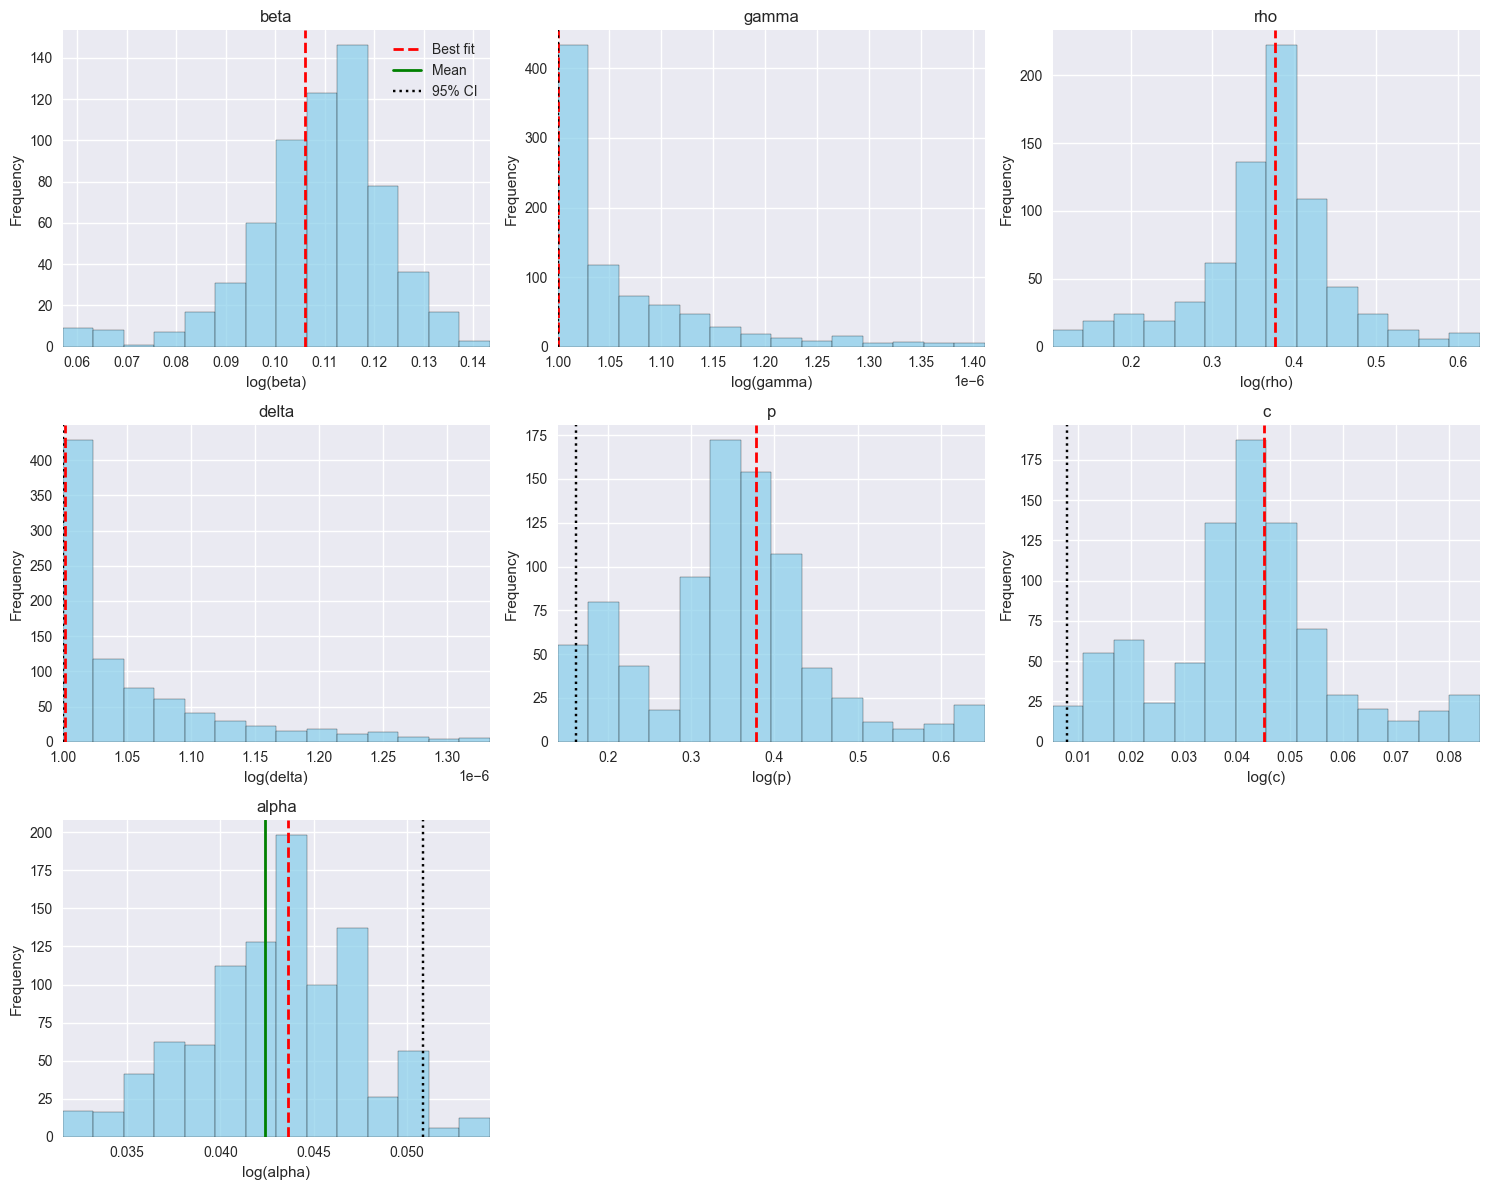

In [40]:
# %% Improved Parameter Distribution Plots - Focus on Main Distribution
# Load existing bootstrap results from tracheal folder
strain = "h5n1(2022)"
location = "tracheal"
results_dir = f"/Users/arjansuri/Desktop/Coding/TCU/BirdFlu/code/model3/{strain}/{location}/bootstrap_results"
results_prefix = f"{results_dir}/{strain}_{location}"

# Load the existing results
bootstrap_params = np.loadtxt(f"{results_prefix}_params.txt", delimiter=",")
bootstrap_ssr = np.loadtxt(f"{results_prefix}_ssr.txt", delimiter=",")

# Filter successful samples
successful_mask = bootstrap_ssr < 1e6
successful_params = bootstrap_params[successful_mask]

print(f"Plotting {len(successful_params)} successful bootstrap samples")

# Calculate parameter statistics
param_names = ['beta', 'gamma', 'rho', 'delta', 'p', 'c', 'alpha']
param_stats = {}

for i, name in enumerate(param_names):
    param_values = successful_params[:, i]
    param_stats[name] = {
        'mean': np.mean(param_values),
        'ci_low': np.percentile(param_values, 2.5),
        'ci_high': np.percentile(param_values, 97.5)
    }

# Focus on the main distribution by removing extreme outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, name in enumerate(param_names):
    if i < len(axes):
        ax = axes[i]
        param_values = successful_params[:, i]  # Already logged
        
        # Remove extreme outliers to focus on main distribution
        q1 = np.percentile(param_values, 25)
        q3 = np.percentile(param_values, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # Keep data within reasonable bounds for plotting
        main_data = param_values[(param_values >= lower_bound) & (param_values <= upper_bound)]
        
        print(f"{name}: {len(main_data)}/{len(param_values)} samples in main distribution")
        
        # Use the range of main data for binning
        if len(main_data) > 10:  # Need enough data points
            # Create bins focused on main distribution
            bins = np.linspace(np.min(main_data), np.max(main_data), 15)
            ax.hist(main_data, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
            ax.set_xlim(np.min(main_data), np.max(main_data))
        else:
            # Fallback to all data with fewer bins
            ax.hist(param_values, bins=8, alpha=0.7, color='skyblue', edgecolor='black')
            
        # Add reference lines
        ax.axvline(best_params[i], color='r', linestyle='--', linewidth=2, label='Best fit')
        ax.axvline(param_stats[name]['mean'], color='g', linestyle='-', linewidth=2, label='Mean')
        ax.axvline(param_stats[name]['ci_low'], color='k', linestyle=':', label='95% CI')
        ax.axvline(param_stats[name]['ci_high'], color='k', linestyle=':')
        
        ax.set_xlabel(f'log({name})')
        ax.set_title(f'{name}')
        ax.set_ylabel('Frequency')
        
        if i == 0:
            ax.legend()

# Remove empty subplots
for i in range(len(param_names), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(f"{results_prefix}_param_distributions_focused.png", dpi=300, bbox_inches='tight')
plt.show()